# NER e Agrupamento de Inovacoes Tecnologicas no Agronegocio

## Versao final v3 (corrigida)

**Correcoes aplicadas nesta versao:**

- `PipelineConfig` corrigida: adicionado decorator `@dataclass` (sem ele, `__init__` nao era gerado e `PipelineConfig(input_path=...)` lancava `TypeError`).
- `seeds_cluster` usa `field(default_factory=...)` (boa pratica com tipos mutaveis em dataclasses).
- `extrair_spans_dicionario`: correcao de `IndexError` quando `match.end()` era igual a `len(mapa_posicoes)` -- indice fora do range. Adicionado `min()` para clampar o indice.
- Imports limpos: removidos `argparse`, `math` e `defaultdict` (nao eram usados em lugar algum).
- Texto de teste na celula de offsets corrigido: `'intelig?ncia'` era mojibake -- substituido por `'inteligencia artificial'` com acentos corretos.
- `Image` importada explicitamente na celula de visualizacoes (`from IPython.display import Image`) -- sem isso a celula lancava `NameError`.
- Celula de resumo de resultados usa `.get()` seguro para evitar `KeyError` em chaves opcionais.
- Strings com caracteres especiais nos docstrings substituidas por versoes ASCII-safe para compatibilidade maxima.
- Notebook continua autocontido, sem importar arquivos `.py` externos.

> O NER e treinado com spaCy por supervisao fraca. O BERTimbau, quando disponivel,
> e usado apenas para embeddings dos textos.


## 1. Dependencias

In [1]:
import importlib.util
import subprocess
import sys


def ensure_package(package_name, import_name=None, optional=False):
    import_name = import_name or package_name
    if importlib.util.find_spec(import_name) is not None:
        print(f'OK: {import_name}')
        return
    try:
        print(f'Instalando {package_name}...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', package_name])
    except Exception as exc:
        if optional:
            print(f'AVISO: {package_name} nao foi instalado. O notebook usara fallback. Erro: {exc}')
        else:
            raise


for package_name, import_name in [
    ('pandas', 'pandas'),
    ('numpy', 'numpy'),
    ('scikit-learn', 'sklearn'),
    ('spacy', 'spacy'),
    ('matplotlib', 'matplotlib'),
    ('openpyxl', 'openpyxl'),
]:
    ensure_package(package_name, import_name)

ensure_package('transformers', 'transformers', optional=True)
ensure_package('accelerate', 'accelerate', optional=True)


OK: pandas
OK: numpy
OK: sklearn
OK: spacy
OK: matplotlib
OK: openpyxl
OK: transformers
OK: accelerate


## 2. Configuracao do arquivo de entrada

In [2]:
from pathlib import Path

INPUT_PATH_MANUAL = None  # Opcional: informe um caminho como '/kaggle/input/dataset/arquivo.tsv'
OUTPUT_DIR = Path('resultados_inovacoes_agro_final')
ZIP_PATH = Path('entrega_inovacoes_agro_final.zip')
PREFER_TRANSFORMER = True


def localizar_arquivo_tabular():
    if INPUT_PATH_MANUAL:
        caminho = Path(INPUT_PATH_MANUAL)
        if not caminho.exists():
            raise FileNotFoundError(f'Arquivo informado nao existe: {caminho}')
        return caminho

    extensoes = ('.tsv', '.csv', '.xlsx', '.xls', '.json', '.jsonl', '.parquet')
    candidatos = []
    for base in [Path('/kaggle/input'), Path.cwd()]:
        if base.exists():
            candidatos.extend([p for p in base.rglob('*') if p.is_file() and p.suffix.lower() in extensoes])
    candidatos = sorted(candidatos, key=lambda p: (p.suffix.lower() != '.tsv', len(str(p)), str(p)))
    if candidatos:
        print('Arquivo detectado automaticamente:', candidatos[0])
        return candidatos[0]

    try:
        from google.colab import files
        print('Nenhum arquivo local encontrado. Faca upload do CSV/TSV/XLSX:')
        uploaded = files.upload()
        if not uploaded:
            raise FileNotFoundError('Nenhum arquivo enviado.')
        return Path(next(iter(uploaded.keys())))
    except Exception as exc:
        raise FileNotFoundError(
            'Nenhum arquivo tabular foi encontrado. No Kaggle, adicione o dataset; '
            'no Colab, faca upload; ou preencha INPUT_PATH_MANUAL.'
        ) from exc


INPUT_PATH = localizar_arquivo_tabular()
print('Arquivo de entrada:', INPUT_PATH)


Arquivo detectado automaticamente: /kaggle/input/datasets/georgekurokijr/dl-2024/dadosTextosCientificos.tsv
Arquivo de entrada: /kaggle/input/datasets/georgekurokijr/dl-2024/dadosTextosCientificos.tsv


## 3. Imports e constantes

In [3]:
from __future__ import annotations

# CORRECAO: removidos 'argparse', 'math' e 'defaultdict' -- nao eram usados
import json
import random
import re
import shutil
import unicodedata
from collections import Counter
from dataclasses import dataclass, field  # field adicionado para seeds_cluster
from itertools import combinations
from pathlib import Path
from typing import Any

import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt

import numpy as np
import pandas as pd
import spacy
from spacy.training import Example
from spacy.util import compounding, minibatch

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    adjusted_rand_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_score,
)
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import normalize

RANDOM_STATE = 42
MODEL_NAME = 'neuralmind/bert-base-portuguese-cased'

TITLE_CANDIDATES = [
    'titulo_publico',
    'titulo',
    'title',
    'nome_publico',
    'projeto',
    'nome_projeto',
]

DESCRIPTION_CANDIDATES = [
    'descricao_publica',
    'descricao',
    'description',
    'resumo',
    'abstract',
    'texto',
]

LABEL_ORDER = [
    'TECNOLOGIA',
    'EQUIPAMENTO',
    'PRATICA_PROCESSO',
    'INSUMO',
    'CADEIA_PRODUTIVA',
    'APLICACAO',
    'BENEFICIO',
    'DESAFIO',
    'INDICADOR',
]


## 4. Dicionario de termos do agronegocio

In [4]:
DICIONARIO_AGRO: dict[str, list[str]] = {
    "TECNOLOGIA": [
        "inteligencia artificial",
        "IA",
        "aprendizado de maquina",
        "machine learning",
        "aprendizado profundo",
        "deep learning",
        "visao computacional",
        "internet das coisas",
        "IoT",
        "big data",
        "computacao em nuvem",
        "computacao de borda",
        "edge computing",
        "blockchain",
        "smart contract",
        "gemeo digital",
        "digital twin",
        "sensoriamento remoto",
        "geoprocessamento",
        "sistema de informacao geografica",
        "SIG",
        "GNSS",
        "GPS",
        "telemetria",
        "5G",
        "LoRa",
        "LoRaWAN",
        "RFID",
        "NFC",
        "automacao agricola",
        "robotica agricola",
        "modelagem preditiva",
        "analise preditiva",
        "modelos generativos",
        "imagens multiespectrais",
        "imagens hiperespectrais",
        "LiDAR",
        "fusao de sensores",
        "plataforma digital",
        "aplicativo movel",
        "sistema de apoio a decisao",
        "software de gestao rural",
        "rastreabilidade digital",
        "monitoramento remoto",
        "algoritmo",
        "rede neural",
        "aprendizado supervisionado",
        "aprendizado nao supervisionado",
    ],
    "EQUIPAMENTO": [
        "drone",
        "drones",
        "VANT",
        "veiculo aereo nao tripulado",
        "satelite",
        "sensor de umidade",
        "sensor de solo",
        "sensor optico",
        "sensor multiespectral",
        "sensor hiperespectral",
        "sensor termico",
        "sensor climatico",
        "sensor de temperatura",
        "sensor de pH",
        "estacao meteorologica",
        "estacao agrometeorologica",
        "armadilha inteligente",
        "camera multiespectral",
        "camera hiperespectral",
        "camera termica",
        "robo agricola",
        "trator autonomo",
        "pulverizador autonomo",
        "pulverizador seletivo",
        "colheitadeira",
        "semeadora",
        "plantadeira",
        "ordenhadeira robotizada",
        "brinco eletronico",
        "coleira inteligente",
        "balanca automatica",
        "silo inteligente",
        "clorofilometro",
        "penetrometro",
        "controlador de irrigacao",
        "pivo central inteligente",
        "medidor de vazao",
        "monitor de produtividade",
        "veiculo terrestre nao tripulado",
        "distribuidor de fertilizantes",
        "maquina de visao",
    ],
    "PRATICA_PROCESSO": [
        "agricultura de precisao",
        "agricultura digital",
        "agricultura 4.0",
        "agricultura inteligente",
        "agricultura regenerativa",
        "plantio direto",
        "integracao lavoura-pecuaria-floresta",
        "ILPF",
        "manejo integrado de pragas",
        "MIP",
        "controle biologico",
        "manejo em taxa variavel",
        "aplicacao em taxa variavel",
        "pulverizacao de precisao",
        "pulverizacao seletiva",
        "irrigacao de precisao",
        "irrigacao inteligente",
        "fertirrigacao",
        "semeadura de precisao",
        "monitoramento em tempo real",
        "rastreabilidade",
        "manejo conservacionista",
        "rotacao de culturas",
        "fixacao biologica de nitrogenio",
        "FBN",
        "cultivo protegido",
        "hidroponia",
        "agrofloresta",
        "manejo de pastagem",
        "confinamento de precisao",
        "pecuaria de precisao",
        "bem-estar animal",
        "processamento minimo",
        "secagem de graos",
        "armazenagem inteligente",
        "pos-colheita",
        "controle de qualidade",
        "classificacao automatica",
        "rastreabilidade da cadeia",
        "biofortificacao",
        "melhoramento genetico",
        "edicao genica",
    ],
    "INSUMO": [
        "bioinsumo",
        "bioinsumos",
        "biofertilizante",
        "fertilizante organico",
        "fertilizante mineral",
        "inoculante",
        "inoculantes",
        "biopesticida",
        "bioinseticida",
        "biofungicida",
        "biocontrole",
        "defensivo agricola",
        "adjuvante",
        "sementes certificadas",
        "sementes tratadas",
        "cultivar",
        "genotipo",
        "muda",
        "substrato",
        "composto organico",
        "corretivo de solo",
        "calcario",
        "gesso agricola",
        "microrganismos",
        "fungos entomopatogenicos",
        "bacterias promotoras de crescimento",
        "extrato vegetal",
        "oleo essencial",
        "nutriente",
        "proteina vegetal",
        "enzima",
        "biopolimero",
    ],
    "CADEIA_PRODUTIVA": [
        "soja",
        "milho",
        "algodao",
        "cafe",
        "cana-de-acucar",
        "cana de acucar",
        "arroz",
        "feijao",
        "trigo",
        "cacau",
        "fruticultura",
        "horticultura",
        "olericultura",
        "floricultura",
        "silvicultura",
        "aquicultura",
        "piscicultura",
        "avicultura",
        "suinocultura",
        "bovinocultura",
        "bovinocultura de corte",
        "bovinocultura de leite",
        "pecuaria leiteira",
        "ovinocultura",
        "caprinocultura",
        "apicultura",
        "mel",
        "leite",
        "carne bovina",
        "carne suina",
        "aves",
        "ovos",
        "mandioca",
        "tomate",
        "uva",
        "citros",
        "laranja",
        "banana",
        "maca",
        "manga",
        "castanhas",
        "açaí",
        "acai",
        "agroindustria",
        "industria de alimentos",
        "alimentos",
        "graos",
        "sementes",
        "florestas plantadas",
    ],
    "APLICACAO": [
        "controle de pragas",
        "controle de doencas",
        "monitoramento de lavouras",
        "monitoramento de culturas",
        "monitoramento de pastagens",
        "previsao de safra",
        "estimativa de produtividade",
        "mapeamento de produtividade",
        "diagnostico fitossanitario",
        "deteccao de plantas daninhas",
        "deteccao de falhas de plantio",
        "controle de irrigacao",
        "gestao de irrigacao",
        "gestao de fazendas",
        "gestao rural",
        "gestao de rebanho",
        "monitoramento animal",
        "classificacao de graos",
        "classificacao de sementes",
        "analise de solo",
        "analise foliar",
        "analise de qualidade",
        "rastreabilidade de alimentos",
        "seguranca alimentar",
        "logistica agricola",
        "comercializacao agricola",
        "mercado agropecuario",
        "agricultura familiar",
        "tomada de decisao",
        "assistencia tecnica",
        "extensao rural",
        "certificacao",
        "rotulagem nutricional",
    ],
    "BENEFICIO": [
        "aumento de produtividade",
        "ganho de produtividade",
        "reducao de custos",
        "economia de agua",
        "economia de energia",
        "uso eficiente da agua",
        "uso eficiente de insumos",
        "sustentabilidade",
        "producao sustentavel",
        "reducao de perdas",
        "reducao de desperdicio",
        "reducao de impacto ambiental",
        "mitigacao de emissao",
        "sequestro de carbono",
        "conservacao do solo",
        "conservacao da agua",
        "melhoria da qualidade",
        "seguranca do alimento",
        "agregacao de valor",
        "diferenciacao de produto",
        "bem-estar animal",
        "resiliencia climatica",
        "renda do produtor",
        "competitividade",
        "eficiencia operacional",
        "baixa toxicidade",
        "baixo custo",
    ],
    "DESAFIO": [
        "pragas",
        "doencas",
        "plantas daninhas",
        "seca",
        "deficit hidrico",
        "estresse hidrico",
        "estresse termico",
        "mudancas climaticas",
        "variabilidade climatica",
        "degradacao do solo",
        "erosao",
        "compactacao do solo",
        "perdas pos-colheita",
        "desperdicio de alimentos",
        "baixa produtividade",
        "alto custo",
        "escassez de mao de obra",
        "resistencia a defensivos",
        "contaminacao",
        "rastreabilidade limitada",
        "assimetria de informacao",
        "dificuldade de acesso a credito",
        "barreiras logisticas",
        "variacao de preco",
        "emissao de gases de efeito estufa",
        "gases de efeito estufa",
        "bem-estar animal",
        "seguranca alimentar",
    ],
    "INDICADOR": [
        "produtividade",
        "rendimento",
        "qualidade",
        "umidade do solo",
        "temperatura",
        "pH",
        "NDVI",
        "indice de vegetacao",
        "biomassa",
        "vigor vegetativo",
        "taxa de germinacao",
        "teor de proteina",
        "teor de umidade",
        "teor de oleo",
        "materia seca",
        "conversao alimentar",
        "ganho de peso",
        "emissao de carbono",
        "pegada de carbono",
        "eficiencia de uso da agua",
        "eficiencia de uso de nitrogenio",
        "vida util",
        "shelf life",
        "custo operacional",
        "receita",
        "margem",
        "retorno economico",
        "TRL",
        "maturidade tecnologica",
    ],
}

## 5. Dados auxiliares e PipelineConfig

In [5]:
TERMOS_AGRO_ADICIONAIS = [
    "agronegocio",
    "agropecuaria",
    "agroindustrial",
    "agricola",
    "agricultura",
    "lavoura",
    "cultivo",
    "plantio",
    "colheita",
    "safra",
    "solo",
    "sementes",
    "alimento",
    "alimentos",
    "industria de alimentos",
    "producao rural",
    "pecuaria",
    "rebanho",
    "pastagem",
    "irrigacao",
    "fertilizante",
    "bioinsumo",
    "agtech",
    "fazenda",
    "produtor rural",
]

EXEMPLOS_NEGATIVOS_EXPLICITOS = [
    "Em 2024, o projeto recebeu nota 8,5 e foi concluido em 12 meses.",
    "A equipe realizou tres reunioes e produziu cinco relatorios tecnicos.",
    "O software administrativo foi atualizado para a versao 7.2.",
    "Brasil, Brasilia e Sao Paulo foram citados apenas como locais institucionais.",
    "O estudo analisou os resultados e apresentou uma conclusao geral.",
    "Foram adquiridos 10 computadores e 25 cadeiras para o laboratorio.",
    "A organizacao publicou o documento em formato PDF no mes de maio.",
    "O codigo 12345 identifica o processo interno da instituicao.",
    "Pesquisadores participaram de um congresso e apresentaram dois trabalhos.",
    "A plataforma academica registrou 150 usuarios durante o semestre.",
]

CASOS_DESAFIO = [
    {
        "texto": "Em 2025, o relatorio numero 17 foi aprovado sem alteracoes.",
        "entidades": [],
    },
    {
        "texto": "O drone coletou imagens multiespectrais para o monitoramento de lavouras de soja.",
        "entidades": [
            ("drone", "EQUIPAMENTO"),
            ("imagens multiespectrais", "TECNOLOGIA"),
            ("monitoramento de lavouras", "APLICACAO"),
            ("soja", "CADEIA_PRODUTIVA"),
        ],
    },
    {
        "texto": "A inteligencia artificial estimou a produtividade do milho sem classificar o ano 2024 como entidade.",
        "entidades": [
            ("inteligencia artificial", "TECNOLOGIA"),
            ("produtividade", "INDICADOR"),
            ("milho", "CADEIA_PRODUTIVA"),
        ],
    },
    {
        "texto": "O plantio direto e a rotacao de culturas contribuiram para a conservacao do solo.",
        "entidades": [
            ("plantio direto", "PRATICA_PROCESSO"),
            ("rotacao de culturas", "PRATICA_PROCESSO"),
            ("conservacao do solo", "BENEFICIO"),
        ],
    },
    {
        "texto": "A equipe comprou 12 computadores, publicou um PDF e visitou Brasilia.",
        "entidades": [],
    },
    {
        "texto": "Um sensor de umidade apoiou o controle de irrigacao e a economia de agua na producao de cafe.",
        "entidades": [
            ("sensor de umidade", "EQUIPAMENTO"),
            ("controle de irrigacao", "APLICACAO"),
            ("economia de agua", "BENEFICIO"),
            ("cafe", "CADEIA_PRODUTIVA"),
        ],
    },
    {
        "texto": "O codigo 12345 e a versao 8.1 pertencem ao sistema administrativo.",
        "entidades": [],
    },
]

STOPWORDS_PT_BASE = [
    "a",
    "o",
    "as",
    "os",
    "um",
    "uma",
    "uns",
    "umas",
    "de",
    "do",
    "da",
    "dos",
    "das",
    "em",
    "no",
    "na",
    "nos",
    "nas",
    "por",
    "pelo",
    "pela",
    "pelos",
    "pelas",
    "para",
    "com",
    "sem",
    "sob",
    "sobre",
    "entre",
    "ate",
    "apos",
    "antes",
    "e",
    "ou",
    "mas",
    "porem",
    "contudo",
    "que",
    "se",
    "quando",
    "como",
    "porque",
    "pois",
    "tambem",
    "ainda",
    "ja",
    "ser",
    "estar",
    "ter",
    "haver",
    "fazer",
    "foi",
    "foram",
    "era",
    "eram",
    "sao",
    "esta",
    "estao",
    "tem",
    "têm",
    "pode",
    "podem",
    "deve",
    "devem",
    "mais",
    "menos",
    "muito",
    "muita",
    "muitos",
    "muitas",
    "ao",
    "aos",
    "partir",
    "projeto",
    "projetos",
    "desenvolvimento",
    "desenvolver",
    "desenvolvido",
    "solucao",
    "solucoes",
    "sistema",
    "sistemas",
    "processo",
    "processos",
    "produto",
    "produtos",
    "tecnologia",
    "tecnologias",
    "uso",
    "utilizacao",
    "aplicacao",
    "aplicacoes",
    "metodo",
    "metodos",
    "modelo",
    "modelos",
    "analise",
    "avaliacao",
    "estudo",
    "pesquisa",
    "dados",
    "informacoes",
    "empresa",
    "empresas",
    "area",
    "areas",
    "setor",
    "setores",
    "objetivo",
    "objetivos",
    "resultado",
    "resultados",
    "forma",
    "meio",
    "parte",
    "tipo",
    "nivel",
    "presente",
    "proposta",
    "nao",
    "alem",
    "assim",
]

# CORRECAO: adicionado @dataclass -- sem ele __init__ nao e gerado automaticamente
# e PipelineConfig(input_path=...) lancaria TypeError em tempo de execucao
@dataclass
class PipelineConfig:
    input_path: Path
    output_dir: Path
    zip_path: Path
    prefer_transformer: bool = True
    save_model: bool = True
    max_sentencas_ner: int = 1400
    proporcao_negativos: float = 0.25
    ner_epochs: int = 30
    ner_patience: int = 6
    max_textos_embeddings: int = 1200
    batch_size: int = 16
    max_len: int = 256
    min_k: int = 2
    max_k: int = 15
    # CORRECAO: field(default_factory=...) para evitar mutavel compartilhado entre instancias
    seeds_cluster: tuple = field(default_factory=lambda: (13, 42, 77, 101, 123))


def normalizar_texto(texto: Any) -> str:
    texto = corrigir_mojibake(texto).strip().casefold()
    texto = unicodedata.normalize("NFD", texto)
    texto = "".join(c for c in texto if not unicodedata.combining(c))
    texto = re.sub(r"\s+", " ", texto)
    return texto

def normalizar_para_match(texto: Any) -> str:
    texto = corrigir_mojibake(texto).casefold()
    texto = unicodedata.normalize("NFD", texto)
    return "".join(c for c in texto if not unicodedata.combining(c))

SINAIS_MOJIBAKE = ("Ã", "Â", "�", "¤", "¢", "§", "©")

def pontuar_ruido_textual(texto: Any) -> int:
    texto = "" if texto is None else str(texto)
    return sum(texto.count(sinal) * 10 for sinal in SINAIS_MOJIBAKE) + texto.count("??") * 5

def corrigir_mojibake(texto: Any) -> str:
    """Corrige mojibake comum sem alterar textos que ja estao bons."""
    texto = "" if texto is None else str(texto)
    candidatos = [texto]
    for encoding in ("latin1", "cp1252"):
        try:
            candidatos.append(texto.encode(encoding, errors="strict").decode("utf-8", errors="strict"))
        except Exception:
            pass
    return min(candidatos, key=pontuar_ruido_textual)

def normalizar_com_mapa(texto: Any) -> tuple[str, list[int]]:
    """Normaliza para matching e preserva mapa de posicoes do texto original."""
    texto = corrigir_mojibake(texto)
    saida: list[str] = []
    mapa: list[int] = []
    for posicao, caractere in enumerate(texto):
        normalizado = unicodedata.normalize("NFD", caractere.casefold())
        normalizado = "".join(c for c in normalizado if not unicodedata.combining(c))
        for c in normalizado:
            saida.append(c)
            mapa.append(posicao)
    return "".join(saida), mapa

def normalizar_nome_coluna(nome: str) -> str:
    nome = normalizar_texto(nome)
    return re.sub(r"[^a-z0-9]+", "_", nome).strip("_")

def encontrar_coluna(df: pd.DataFrame, candidatos: list[str]) -> str | None:
    mapa = {normalizar_nome_coluna(c): c for c in df.columns}
    for candidato in candidatos:
        if candidato in mapa:
            return mapa[candidato]
    return None

## 6. Leitura de dados e utilitarios

In [6]:
def read_table_robusto(file_path: Path) -> tuple[pd.DataFrame, dict[str, str]]:
    file_path = Path(file_path)
    lower = file_path.name.lower()
    metadata: dict[str, str] = {"arquivo": str(file_path)}

    if lower.endswith(".xlsx"):
        metadata.update({"formato": "xlsx", "encoding": "n/a", "sep": "n/a"})
        return pd.read_excel(file_path), metadata
    if lower.endswith(".parquet"):
        metadata.update({"formato": "parquet", "encoding": "n/a", "sep": "n/a"})
        return pd.read_parquet(file_path), metadata
    if lower.endswith(".jsonl"):
        metadata.update({"formato": "jsonl", "encoding": "utf-8", "sep": "n/a"})
        return pd.read_json(file_path, lines=True), metadata
    if lower.endswith(".json"):
        metadata.update({"formato": "json", "encoding": "utf-8", "sep": "n/a"})
        return pd.read_json(file_path), metadata

    if lower.endswith(".tsv"):
        separadores: list[str | None] = ["\t"]
    elif lower.endswith(".csv"):
        separadores = [None, ";", ",", "\t"]
    else:
        raise ValueError(f"Formato nao suportado: {file_path}")

    erros = []
    for encoding in ["utf-8", "utf-8-sig", "latin-1", "cp1252"]:
        for sep in separadores:
            try:
                df_lido = pd.read_csv(file_path, encoding=encoding, sep=sep, engine="python")
                if df_lido.shape[1] >= 2:
                    metadata.update(
                        {
                            "formato": "tabular",
                            "encoding": encoding,
                            "sep": "\\t" if sep == "\t" else str(sep),
                        }
                    )
                    return df_lido, metadata
            except Exception as exc:  # pragma: no cover - diagnostic path
                erros.append(f"{encoding}/{sep}: {type(exc).__name__}")

    raise RuntimeError("Nao foi possivel ler o arquivo. Tentativas: " + " | ".join(erros[-8:]))

def limpar_descricao(texto: Any) -> str:
    texto = corrigir_mojibake(texto)
    texto = re.sub(r"https?://\S+|www\.\S+", " ", texto)
    texto = re.sub(r"\s+", " ", texto).strip()
    return texto

def remover_abertura_generica(texto: str) -> str:
    padroes = [
        r"^o presente (projeto|trabalho|estudo) (tem como objetivo|objetiva|visa)\s*",
        r"^este (projeto|trabalho|estudo) (tem como objetivo|objetiva|visa)\s*",
        r"^o objetivo (geral )?(deste|desse|do presente) (projeto|trabalho|estudo) (e|consiste em)\s*",
        r"^a presente proposta (tem como objetivo|objetiva|visa)\s*",
    ]
    resultado = texto.strip()
    for padrao in padroes:
        resultado = re.sub(padrao, "", resultado, flags=re.IGNORECASE)
    return resultado.strip(" .;:-")

def curar_dicionario() -> tuple[dict[str, list[str]], pd.DataFrame, pd.DataFrame]:
    vistos: dict[str, str] = {}
    curado: dict[str, list[str]] = {label: [] for label in LABEL_ORDER}
    duplicados: list[dict[str, str]] = []
    linhas: list[dict[str, str]] = []

    for label in LABEL_ORDER:
        termos_limpos = sorted({str(t).strip() for t in DICIONARIO_AGRO[label] if str(t).strip()})
        for termo in termos_limpos:
            normalizado = normalizar_texto(termo)
            if normalizado in vistos:
                if vistos[normalizado] != label:
                    duplicados.append(
                        {
                            "termo": termo,
                            "termo_normalizado": normalizado,
                            "categoria_original": label,
                            "categoria_mantida": vistos[normalizado],
                        }
                    )
                continue
            vistos[normalizado] = label
            curado[label].append(termo)
            linhas.append({"categoria": label, "termo": termo, "termo_normalizado": normalizado})

    return curado, pd.DataFrame(linhas), pd.DataFrame(duplicados)

def carregar_corpus(input_path: Path) -> tuple[pd.DataFrame, dict[str, Any]]:
    df_bruto, metadata = read_table_robusto(input_path)
    col_titulo = encontrar_coluna(df_bruto, TITLE_CANDIDATES)
    col_descricao = encontrar_coluna(df_bruto, DESCRIPTION_CANDIDATES)

    colunas_textuais = [c for c in df_bruto.columns if df_bruto[c].dtype == "object"]
    if col_descricao is None:
        if not colunas_textuais:
            raise ValueError("Nenhuma coluna textual foi encontrada.")
        col_descricao = colunas_textuais[-1]
    if col_titulo is None:
        col_titulo = colunas_textuais[0] if len(colunas_textuais) > 1 else col_descricao

    df_base = pd.DataFrame(
        {
            "titulo": df_bruto[col_titulo].fillna("").astype(str).str.strip(),
            "descricao": df_bruto[col_descricao].fillna("").astype(str).map(limpar_descricao),
        }
    )
    df_base = df_base[df_base["descricao"].str.len() >= 80].copy()
    df_base["descricao_normalizada"] = df_base["descricao"].map(normalizar_texto)
    df_base = df_base.drop_duplicates("descricao_normalizada").reset_index(drop=True)
    df_base["documento_id"] = np.arange(len(df_base))
    df_base["texto_cluster"] = df_base["descricao"].map(remover_abertura_generica)

    metadata.update(
        {
            "linhas_brutas": int(len(df_bruto)),
            "colunas": list(df_bruto.columns),
            "coluna_titulo": col_titulo,
            "coluna_descricao": col_descricao,
            "textos_validos_sem_duplicacao": int(len(df_base)),
        }
    )
    return df_base, metadata

PadraoEntidade = tuple[str, re.Pattern[str]]

def criar_matcher(dicionario: dict[str, list[str]]) -> tuple[spacy.Language, list[PadraoEntidade]]:
    nlp_regras = spacy.blank("pt")
    nlp_regras.add_pipe("sentencizer")
    padroes: list[PadraoEntidade] = []
    for label, termos in dicionario.items():
        for termo in sorted(set(termos), key=len, reverse=True):
            termo_norm = normalizar_texto(termo)
            regex_termo = re.escape(termo_norm).replace(r"\ ", r"\s+")
            padrao = re.compile(rf"(?<!\w){regex_termo}(?!\w)", flags=re.IGNORECASE)
            padroes.append((label, padrao))
    return nlp_regras, padroes

def extrair_spans_dicionario(
    texto: str,
    nlp_regras: spacy.Language,
    matcher: list[PadraoEntidade],
) -> list[tuple[int, int, str]]:
    texto_original = str(texto)
    texto_norm, mapa_posicoes = normalizar_com_mapa(texto_original)
    # CORRECAO: guarda defensivo para mapa_posicoes vazio
    if not mapa_posicoes:
        return []

    candidatos = []
    for label, padrao in matcher:
        for match in padrao.finditer(texto_norm):
            inicio = mapa_posicoes[match.start()]
            # CORRECAO: match.end() pode igualar len(mapa_posicoes), causando IndexError.
            # Clampamos com min() para garantir acesso seguro.
            fim_idx = min(match.end() - 1, len(mapa_posicoes) - 1)
            fim = mapa_posicoes[fim_idx] + 1
            candidatos.append((inicio, fim, label))

    selecionados: list[tuple[int, int, str]] = []
    ocupados: list[tuple[int, int]] = []
    for inicio, fim, label in sorted(candidatos, key=lambda x: (-(x[1] - x[0]), x[0], x[2])):
        if any(inicio < fim_ocupado and fim > inicio_ocupado for inicio_ocupado, fim_ocupado in ocupados):
            continue
        selecionados.append((inicio, fim, label))
        ocupados.append((inicio, fim))
    return sorted(selecionados, key=lambda x: (x[0], -(x[1] - x[0]), x[2]))

def construir_filtro_agro(dicionario: dict[str, list[str]]) -> list[tuple[str, re.Pattern[str]]]:
    categorias_filtro = [
        "CADEIA_PRODUTIVA",
        "PRATICA_PROCESSO",
        "INSUMO",
        "EQUIPAMENTO",
        "APLICACAO",
        "DESAFIO",
    ]
    termos_filtro = set(TERMOS_AGRO_ADICIONAIS)
    for categoria in categorias_filtro:
        termos_filtro.update(dicionario[categoria])

    excluir = {
        normalizar_texto(t)
        for t in {
            "praga",
            "doenca",
            "seca",
            "leite",
            "arroz",
            "cafe",
            "milho",
            "soja",
            "sensor",
            "satelite",
            "produto",
            "processo",
            "sistema",
        }
    }
    termos = sorted(
        {
            normalizar_texto(t)
            for t in termos_filtro
            if len(normalizar_texto(t)) >= 4 and normalizar_texto(t) not in excluir
        },
        key=len,
        reverse=True,
    )
    return [(termo, re.compile(rf"(?<!\w){re.escape(termo)}(?!\w)", flags=re.IGNORECASE)) for termo in termos]

## 7. NER: matcher, supervisao fraca e treinamento

In [7]:
def filtrar_textos_agro(
    df_base: pd.DataFrame,
    padroes_filtro: list[tuple[str, re.Pattern[str]]],
) -> pd.DataFrame:
    def localizar_termos_agro(texto: str) -> list[str]:
        texto_norm = normalizar_texto(texto)
        return [termo for termo, padrao in padroes_filtro if padrao.search(texto_norm)]

    df_filtrado = df_base.copy()
    df_filtrado["termos_filtro_agro"] = df_filtrado["descricao"].map(localizar_termos_agro)
    df_filtrado["quantidade_termos_agro"] = df_filtrado["termos_filtro_agro"].map(len)
    df_filtrado = df_filtrado[df_filtrado["quantidade_termos_agro"] >= 1].copy().reset_index(drop=True)
    df_filtrado["documento_id"] = np.arange(len(df_filtrado))
    return df_filtrado

def sentencas_documento(texto: str, nlp_regras: spacy.Language) -> list[str]:
    doc = nlp_regras(str(texto))
    saida = []
    for sent in doc.sents:
        frase = sent.text.strip()
        if 30 <= len(frase) <= 600:
            saida.append(frase)
    return saida

def gerar_anotacoes_fracas(
    df_textos: pd.DataFrame,
    nlp_regras: spacy.Language,
    matcher: list[PadraoEntidade],
    config: PipelineConfig,
) -> pd.DataFrame:
    registros_sentencas = []
    for _, row in df_textos.iterrows():
        for ordem, frase in enumerate(sentencas_documento(row["descricao"], nlp_regras)):
            entidades = extrair_spans_dicionario(frase, nlp_regras, matcher)
            registros_sentencas.append(
                {
                    "documento_id": int(row["documento_id"]),
                    "ordem_sentenca": ordem,
                    "texto": frase,
                    "entities": entidades,
                    "possui_entidade": bool(entidades),
                }
            )

    df_sentencas = pd.DataFrame(registros_sentencas)
    if df_sentencas.empty:
        raise ValueError("Nenhuma sentenca foi gerada para supervisao fraca.")

    positivos = df_sentencas[df_sentencas["possui_entidade"]].copy()
    negativos = df_sentencas[~df_sentencas["possui_entidade"]].copy()

    if len(positivos) > config.max_sentencas_ner:
        positivos = positivos.sample(config.max_sentencas_ner, random_state=RANDOM_STATE)

    n_negativos = min(len(negativos), max(30, int(len(positivos) * config.proporcao_negativos)))
    negativos = negativos.sample(n_negativos, random_state=RANDOM_STATE) if n_negativos else negativos.head(0)

    df_negativos_explicitos = pd.DataFrame(
        {
            "documento_id": [-(i + 1) for i in range(len(EXEMPLOS_NEGATIVOS_EXPLICITOS))],
            "ordem_sentenca": 0,
            "texto": EXEMPLOS_NEGATIVOS_EXPLICITOS,
            "entities": [[] for _ in EXEMPLOS_NEGATIVOS_EXPLICITOS],
            "possui_entidade": False,
        }
    )

    return (
        pd.concat([positivos, negativos, df_negativos_explicitos], ignore_index=True)
        .sample(frac=1, random_state=RANDOM_STATE)
        .reset_index(drop=True)
    )

def validar_registros_anotados(
    df_registros: pd.DataFrame,
    nlp_regras: spacy.Language,
) -> tuple[pd.DataFrame, pd.DataFrame, Counter[str]]:
    validos = []
    invalidos = []
    contagem: Counter[str] = Counter()

    for _, row in df_registros.iterrows():
        texto = row["texto"]
        entities = row["entities"]
        doc = nlp_regras.make_doc(texto)
        problema = False
        for inicio, fim, label in entities:
            span = doc.char_span(inicio, fim, label=label, alignment_mode="strict")
            if span is None:
                problema = True
                break
            contagem[label] += 1
        if problema:
            invalidos.append(row.to_dict())
        else:
            validos.append(row.to_dict())

    return pd.DataFrame(validos), pd.DataFrame(invalidos), contagem

def linha_para_exemplo(nlp: spacy.Language, row: pd.Series) -> Example:
    doc = nlp.make_doc(row["texto"])
    return Example.from_dict(doc, {"entities": row["entities"]})

def avaliar_exemplos_spacy(nlp: spacy.Language, examples: list[Example]) -> tuple[dict[str, float], pd.DataFrame]:
    scores = nlp.evaluate(examples)
    gerais = {
        "precision": float(scores.get("ents_p", 0.0)),
        "recall": float(scores.get("ents_r", 0.0)),
        "f1": float(scores.get("ents_f", 0.0)),
    }
    por_tipo = []
    for label, valores in scores.get("ents_per_type", {}).items():
        por_tipo.append(
            {
                "categoria": label,
                "precision": float(valores.get("p", 0.0)),
                "recall": float(valores.get("r", 0.0)),
                "f1": float(valores.get("f", 0.0)),
            }
        )
    return gerais, pd.DataFrame(por_tipo)

def score_span_predictions(
    gold_docs: list[list[tuple[int, int, str]]],
    pred_docs: list[list[tuple[int, int, str]]],
) -> dict[str, float]:
    tp = fp = fn = 0
    for gold, pred in zip(gold_docs, pred_docs):
        gold_set = set(gold)
        pred_set = set(pred)
        tp += len(gold_set & pred_set)
        fp += len(pred_set - gold_set)
        fn += len(gold_set - pred_set)

    precision = tp / (tp + fp) if tp + fp else 0.0
    recall = tp / (tp + fn) if tp + fn else 0.0
    f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0.0
    return {"precision": precision, "recall": recall, "f1": f1, "tp": tp, "fp": fp, "fn": fn}

def treinar_ner_spacy(
    df_anotacoes_validas: pd.DataFrame,
    dicionario: dict[str, list[str]],
    config: PipelineConfig,
) -> tuple[spacy.Language, pd.DataFrame, pd.DataFrame, pd.DataFrame, dict[str, float], pd.DataFrame]:
    if len(df_anotacoes_validas) < 30:
        raise ValueError("Ha poucos exemplos validos para treinar o NER.")

    gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=RANDOM_STATE)
    indices_train, indices_val = next(
        gss.split(df_anotacoes_validas, groups=df_anotacoes_validas["documento_id"])
    )

    df_train = df_anotacoes_validas.iloc[indices_train].reset_index(drop=True)
    df_val = df_anotacoes_validas.iloc[indices_val].reset_index(drop=True)

    nlp_ner = spacy.blank("pt")
    ner = nlp_ner.add_pipe("ner")
    for label in dicionario:
        ner.add_label(label)

    train_examples = [linha_para_exemplo(nlp_ner, row) for _, row in df_train.iterrows()]
    val_examples = [linha_para_exemplo(nlp_ner, row) for _, row in df_val.iterrows()]
    optimizer = nlp_ner.initialize(get_examples=lambda: train_examples)

    historico = []
    best_f1 = -1.0
    best_state = None
    epocas_sem_melhora = 0

    for epoch in range(1, config.ner_epochs + 1):
        random.shuffle(train_examples)
        losses: dict[str, float] = {}
        batches = minibatch(train_examples, size=compounding(8.0, 64.0, 1.001))
        for batch in batches:
            nlp_ner.update(batch, sgd=optimizer, drop=0.25, losses=losses)

        scores = nlp_ner.evaluate(val_examples)
        val_f1 = float(scores.get("ents_f", 0.0))
        val_p = float(scores.get("ents_p", 0.0))
        val_r = float(scores.get("ents_r", 0.0))
        historico.append(
            {
                "epoca": epoch,
                "loss": float(losses.get("ner", np.nan)),
                "val_precision": val_p,
                "val_recall": val_r,
                "val_f1": val_f1,
            }
        )
        print(f"Epoca {epoch:02d} | loss={losses.get('ner', 0):.4f} | P={val_p:.3f} R={val_r:.3f} F1={val_f1:.3f}")

        if val_f1 > best_f1 + 1e-4:
            best_f1 = val_f1
            best_state = nlp_ner.to_bytes()
            epocas_sem_melhora = 0
        else:
            epocas_sem_melhora += 1
            if epocas_sem_melhora >= config.ner_patience:
                print("Early stopping por ausencia de melhora na validacao.")
                break

    if best_state is not None:
        nlp_ner.from_bytes(best_state)

    historico_df = pd.DataFrame(historico)
    metricas_validacao, metricas_validacao_por_tipo = avaliar_exemplos_spacy(nlp_ner, val_examples)
    return nlp_ner, df_train, df_val, historico_df, metricas_validacao, metricas_validacao_por_tipo

def localizar_substring(texto: str, substring: str, label: str) -> tuple[int, int, str]:
    inicio = texto.lower().find(substring.lower())
    if inicio < 0:
        raise ValueError(f"Substring nao encontrada: {substring!r}")
    return inicio, inicio + len(substring), label

## 8. Extracao hibrida de entidades e avaliacao

In [8]:
def avaliar_desafio(
    nlp_ner: spacy.Language,
    nlp_regras: spacy.Language,
    matcher: list[PadraoEntidade],
) -> tuple[dict[str, float], pd.DataFrame, dict[str, float]]:
    gold_docs = [
        [localizar_substring(caso["texto"], substring, label) for substring, label in caso["entidades"]]
        for caso in CASOS_DESAFIO
    ]
    pred_modelo = [
        [(ent.start_char, ent.end_char, ent.label_) for ent in nlp_ner(caso["texto"]).ents]
        for caso in CASOS_DESAFIO
    ]
    pred_dicionario = [
        extrair_spans_dicionario(caso["texto"], nlp_regras, matcher)
        for caso in CASOS_DESAFIO
    ]

    metricas_modelo = score_span_predictions(gold_docs, pred_modelo)
    metricas_dicionario = score_span_predictions(gold_docs, pred_dicionario)
    linhas = []
    for caso, gold, pred_m, pred_d in zip(CASOS_DESAFIO, gold_docs, pred_modelo, pred_dicionario):
        linhas.append(
            {
                "texto": caso["texto"],
                "esperado": "; ".join(f"{caso['texto'][i:f]} [{label}]" for i, f, label in gold),
                "previsto_modelo": "; ".join(f"{caso['texto'][i:f]} [{label}]" for i, f, label in pred_m),
                "previsto_dicionario": "; ".join(f"{caso['texto'][i:f]} [{label}]" for i, f, label in pred_d),
            }
        )
    return metricas_modelo, pd.DataFrame(linhas), metricas_dicionario

def predicao_modelo_valida(texto_entidade: str, label: str, termos_por_label: dict[str, set[str]]) -> bool:
    limpo = texto_entidade.strip()
    normalizado = normalizar_texto(limpo)
    if len(limpo) < 3:
        return False
    if not any(ch.isalpha() for ch in limpo):
        return False
    if re.fullmatch(r"[\d\W_]+", limpo):
        return False
    if label == "CADEIA_PRODUTIVA" and normalizado not in termos_por_label[label]:
        return False
    return True

def extrair_entidades_hibridas(
    texto: str,
    nlp_ner: spacy.Language,
    nlp_regras: spacy.Language,
    matcher: list[PadraoEntidade],
    termos_por_label: dict[str, set[str]],
) -> list[dict[str, Any]]:
    regras = [
        {"inicio": i, "fim": f, "categoria": label, "origem": "dicionario"}
        for i, f, label in extrair_spans_dicionario(texto, nlp_regras, matcher)
    ]

    selecionadas = list(regras)
    doc_modelo = nlp_ner(texto)
    for ent in doc_modelo.ents:
        if not predicao_modelo_valida(ent.text, ent.label_, termos_por_label):
            continue
        if any(ent.start_char < r["fim"] and ent.end_char > r["inicio"] for r in selecionadas):
            continue
        selecionadas.append(
            {
                "inicio": ent.start_char,
                "fim": ent.end_char,
                "categoria": ent.label_,
                "origem": "modelo",
            }
        )
    return sorted(selecionadas, key=lambda x: (x["inicio"], -(x["fim"] - x["inicio"])))

def extrair_df_entidades(
    df_textos: pd.DataFrame,
    nlp_ner: spacy.Language,
    nlp_regras: spacy.Language,
    matcher: list[PadraoEntidade],
    dicionario: dict[str, list[str]],
) -> tuple[pd.DataFrame, pd.DataFrame]:
    termos_por_label = {label: {normalizar_texto(t) for t in termos} for label, termos in dicionario.items()}
    registros_entidades = []
    resumos_documentos = []

    for _, row in df_textos.iterrows():
        entidades = extrair_entidades_hibridas(
            row["descricao"],
            nlp_ner,
            nlp_regras,
            matcher,
            termos_por_label,
        )
        resumo = []
        for ent in entidades:
            trecho = row["descricao"][ent["inicio"] : ent["fim"]]
            registros_entidades.append(
                {
                    "documento_id": int(row["documento_id"]),
                    "titulo": row["titulo"],
                    "entidade": trecho,
                    "entidade_normalizada": normalizar_texto(trecho),
                    "categoria": ent["categoria"],
                    "origem": ent["origem"],
                    "inicio": ent["inicio"],
                    "fim": ent["fim"],
                }
            )
            resumo.append(f"{trecho} [{ent['categoria']}]")

        resumos_documentos.append(
            {
                "documento_id": int(row["documento_id"]),
                "entidades_resumo": "; ".join(resumo),
                "quantidade_entidades": len(entidades),
            }
        )

    df_entidades = pd.DataFrame(
        registros_entidades,
        columns=[
            "documento_id",
            "titulo",
            "entidade",
            "entidade_normalizada",
            "categoria",
            "origem",
            "inicio",
            "fim",
        ],
    )
    return df_entidades, pd.DataFrame(resumos_documentos)

def consolidar_entidades(df_entidades: pd.DataFrame) -> pd.DataFrame:
    if df_entidades.empty:
        return pd.DataFrame(
            columns=[
                "entidade",
                "entidade_normalizada",
                "categoria",
                "frequencia",
                "documentos",
                "origens",
                "exemplos_doc_id",
            ]
        )

    linhas = []
    for entidade_norm, grupo in df_entidades.groupby("entidade_normalizada", sort=False):
        categoria = grupo["categoria"].value_counts().idxmax()
        entidade = grupo["entidade"].value_counts().idxmax()
        docs = sorted({int(x) for x in grupo["documento_id"].tolist()})
        linhas.append(
            {
                "entidade": entidade,
                "entidade_normalizada": entidade_norm,
                "categoria": categoria,
                "frequencia": int(len(grupo)),
                "documentos": int(len(docs)),
                "origens": ";".join(sorted(set(grupo["origem"]))),
                "exemplos_doc_id": ";".join(map(str, docs[:5])),
            }
        )
    return pd.DataFrame(linhas).sort_values(["frequencia", "entidade"], ascending=[False, True])

def gerar_embeddings_transformer(
    textos: list[str],
    config: PipelineConfig,
) -> tuple[np.ndarray | None, dict[str, Any]]:
    if not config.prefer_transformer:
        return None, {"backend": "tfidf_svd", "motivo": "prefer_transformer=False"}

    try:
        import torch
        from transformers import AutoModel, AutoTokenizer
    except Exception as exc:
        return None, {"backend": "tfidf_svd", "motivo": f"transformers_indisponivel: {type(exc).__name__}"}

    try:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
        modelo_bert = AutoModel.from_pretrained(MODEL_NAME).to(device)
        modelo_bert.eval()
        vetores = []
        for inicio in range(0, len(textos), config.batch_size):
            lote = textos[inicio : inicio + config.batch_size]
            encoded = tokenizer(
                lote,
                padding=True,
                truncation=True,
                max_length=config.max_len,
                return_tensors="pt",
            )
            encoded = {k: v.to(device) for k, v in encoded.items()}
            with torch.no_grad():
                outputs = modelo_bert(**encoded)
                mask = encoded["attention_mask"].unsqueeze(-1).expand(outputs.last_hidden_state.size()).float()
                pooled = torch.sum(outputs.last_hidden_state * mask, dim=1) / torch.clamp(mask.sum(dim=1), min=1e-9)
                pooled = torch.nn.functional.normalize(pooled, p=2, dim=1)
            vetores.append(pooled.cpu().numpy())
        return np.vstack(vetores), {"backend": "bertimbau", "modelo": MODEL_NAME, "device": str(device)}
    except Exception as exc:
        return None, {"backend": "tfidf_svd", "motivo": f"falha_transformer: {type(exc).__name__}: {exc}"}

## 9. Embeddings e clusterizacao

In [9]:
def gerar_embeddings_tfidf_svd(textos: list[str]) -> tuple[np.ndarray, dict[str, Any], TfidfVectorizer]:
    stopwords = sorted({normalizar_texto(x) for x in STOPWORDS_PT_BASE})
    vectorizer = TfidfVectorizer(
        max_features=8000,
        stop_words=stopwords,
        ngram_range=(1, 3),
        min_df=2 if len(textos) >= 80 else 1,
        max_df=0.85,
        lowercase=True,
        strip_accents="unicode",
        sublinear_tf=True,
    )
    matrix = vectorizer.fit_transform(textos)
    n_componentes = min(50, matrix.shape[0] - 1, matrix.shape[1] - 1)
    if n_componentes >= 2:
        svd = TruncatedSVD(n_components=n_componentes, random_state=RANDOM_STATE)
        reduzido = svd.fit_transform(matrix)
        variancia = float(svd.explained_variance_ratio_.sum())
    else:
        reduzido = matrix.toarray()
        variancia = 1.0
    return normalize(reduzido), {"backend": "tfidf_svd", "dimensoes": int(reduzido.shape[1]), "variancia": variancia}, vectorizer

def preparar_embeddings(
    df_analise: pd.DataFrame,
    config: PipelineConfig,
) -> tuple[np.ndarray, dict[str, Any], TfidfVectorizer | None]:
    textos = df_analise["texto_cluster"].tolist()
    embeddings_transformer, meta = gerar_embeddings_transformer(textos, config)
    if embeddings_transformer is not None:
        n_componentes = min(50, embeddings_transformer.shape[0] - 1, embeddings_transformer.shape[1])
        pca_cluster = PCA(n_components=n_componentes, random_state=RANDOM_STATE)
        reduzidos = pca_cluster.fit_transform(embeddings_transformer)
        meta.update(
            {
                "dimensoes_originais": int(embeddings_transformer.shape[1]),
                "dimensoes_cluster": int(reduzidos.shape[1]),
                "variancia_pca": float(pca_cluster.explained_variance_ratio_.sum()),
            }
        )
        return normalize(reduzidos), meta, None

    embeddings, fallback_meta, vectorizer = gerar_embeddings_tfidf_svd(textos)
    fallback_meta["motivo"] = meta.get("motivo", "fallback")
    return embeddings, fallback_meta, vectorizer

def estabilidade_ari(lista_labels: list[np.ndarray]) -> float:
    if len(lista_labels) < 2:
        return 1.0
    valores = [adjusted_rand_score(a, b) for a, b in combinations(lista_labels, 2)]
    return float(np.mean(valores))

def selecionar_k(embeddings_cluster: np.ndarray, config: PipelineConfig) -> tuple[pd.DataFrame, int, pd.Series]:
    n_amostras = embeddings_cluster.shape[0]
    max_k_ajustado = min(config.max_k, max(config.min_k, n_amostras // 12), n_amostras - 1)
    ks = list(range(config.min_k, max_k_ajustado + 1))
    resultados = []

    for k in ks:
        labels_por_semente = []
        metricas_semente = []
        for seed in config.seeds_cluster:
            modelo_k = KMeans(n_clusters=k, random_state=seed, n_init=20)
            labels = modelo_k.fit_predict(embeddings_cluster)
            labels_por_semente.append(labels)
            contagens = np.bincount(labels, minlength=k)
            metricas_semente.append(
                {
                    "silhouette": silhouette_score(embeddings_cluster, labels),
                    "davies_bouldin": davies_bouldin_score(embeddings_cluster, labels),
                    "calinski_harabasz": calinski_harabasz_score(embeddings_cluster, labels),
                    "menor_cluster_pct": contagens.min() / len(labels),
                }
            )

        df_m = pd.DataFrame(metricas_semente)
        resultados.append(
            {
                "k": k,
                "silhouette": float(df_m["silhouette"].mean()),
                "silhouette_std": float(df_m["silhouette"].std()),
                "davies_bouldin": float(df_m["davies_bouldin"].mean()),
                "calinski_harabasz": float(df_m["calinski_harabasz"].mean()),
                "estabilidade_ari": estabilidade_ari(labels_por_semente),
                "menor_cluster_pct": float(df_m["menor_cluster_pct"].mean()),
            }
        )

    metricas_cluster = pd.DataFrame(resultados)

    def minmax(serie: pd.Series, inverter: bool = False) -> pd.Series:
        serie = serie.astype(float)
        if np.isclose(serie.max(), serie.min()):
            resultado = pd.Series(np.ones(len(serie)), index=serie.index)
        else:
            resultado = (serie - serie.min()) / (serie.max() - serie.min())
        return 1 - resultado if inverter else resultado

    metricas_cluster["score_composto_bruto"] = (
        0.40 * minmax(metricas_cluster["silhouette"])
        + 0.25 * minmax(metricas_cluster["estabilidade_ari"])
        + 0.15 * minmax(np.log1p(metricas_cluster["calinski_harabasz"]))
        + 0.10 * minmax(metricas_cluster["davies_bouldin"], inverter=True)
        + 0.10 * minmax(metricas_cluster["menor_cluster_pct"])
    )

    if max_k_ajustado > config.min_k:
        complexidade = (metricas_cluster["k"] - config.min_k) / (max_k_ajustado - config.min_k)
    else:
        complexidade = pd.Series(np.zeros(len(metricas_cluster)), index=metricas_cluster.index)

    # Quando a separacao e fraca, muitos clusters tendem a ser artefato do KMeans.
    # A penalizacao torna a escolha mais conservadora e mais defensavel academicamente.
    penalidade_base = 0.18 * complexidade
    if float(metricas_cluster["silhouette"].max()) < 0.10:
        penalidade_base += 0.12 * complexidade
    metricas_cluster["penalidade_complexidade"] = penalidade_base
    metricas_cluster["score_composto"] = metricas_cluster["score_composto_bruto"] - penalidade_base
    metricas_cluster.loc[metricas_cluster["menor_cluster_pct"] < 0.03, "score_composto"] *= 0.75

    candidatos = metricas_cluster
    if float(metricas_cluster["silhouette"].max()) < 0.10:
        limite_conservador = min(6, max_k_ajustado)
        candidatos = metricas_cluster[metricas_cluster["k"] <= limite_conservador]

    best_row = candidatos.sort_values(
        ["score_composto", "silhouette", "estabilidade_ari"],
        ascending=False,
    ).iloc[0]
    return metricas_cluster, int(best_row["k"]), best_row

def termos_por_cluster(df_analise: pd.DataFrame) -> pd.DataFrame:
    stopwords = sorted({normalizar_texto(x) for x in STOPWORDS_PT_BASE})
    vectorizer = TfidfVectorizer(
        max_features=8000,
        stop_words=stopwords,
        ngram_range=(1, 3),
        min_df=2 if len(df_analise) >= 80 else 1,
        max_df=0.85,
        lowercase=True,
        strip_accents="unicode",
        sublinear_tf=True,
    )
    tfidf_matrix = vectorizer.fit_transform(df_analise["texto_cluster"])
    termos = np.array(vectorizer.get_feature_names_out())
    linhas = []
    for cluster_id in sorted(df_analise["cluster"].unique()):
        indices = np.where(df_analise["cluster"].values == cluster_id)[0]
        media = np.asarray(tfidf_matrix[indices].mean(axis=0)).ravel()
        top_idx = media.argsort()[::-1][:20]
        linhas.append(
            {
                "cluster": int(cluster_id),
                "quantidade_textos": int(len(indices)),
                "termos_representativos": ", ".join(termos[top_idx]),
            }
        )
    return pd.DataFrame(linhas)

## 10. Rotulos de clusters, figuras e relatorio

In [10]:
def entidades_e_rotulos_por_cluster(
    df_analise: pd.DataFrame,
    df_entidades: pd.DataFrame,
    cluster_terms_df: pd.DataFrame,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    ids_analise = set(df_analise["documento_id"])
    df_entidades_analise = df_entidades[df_entidades["documento_id"].isin(ids_analise)].copy()
    if df_entidades_analise.empty:
        top_entidades_clusters = pd.DataFrame()
    else:
        df_entidades_analise = df_entidades_analise.merge(
            df_analise[["documento_id", "cluster"]],
            on="documento_id",
            how="left",
        )
        top_entidades_clusters = (
            df_entidades_analise.groupby(["cluster", "categoria", "entidade_normalizada"])
            .size()
            .reset_index(name="frequencia")
            .sort_values(["cluster", "frequencia"], ascending=[True, False])
            .groupby("cluster", group_keys=False)
            .head(20)
        )

    categorias_prioritarias = ["TECNOLOGIA", "APLICACAO", "PRATICA_PROCESSO", "CADEIA_PRODUTIVA", "INSUMO"]
    rotulos = []
    for cluster_id in sorted(df_analise["cluster"].unique()):
        itens: list[str] = []
        if not top_entidades_clusters.empty:
            subset = top_entidades_clusters[
                (top_entidades_clusters["cluster"] == cluster_id)
                & (top_entidades_clusters["categoria"].isin(categorias_prioritarias))
            ]
            itens = subset["entidade_normalizada"].drop_duplicates().head(3).tolist()
        if len(itens) < 2:
            termos_cluster = (
                cluster_terms_df.loc[cluster_terms_df["cluster"] == cluster_id, "termos_representativos"]
                .iloc[0]
                .split(", ")
            )
            itens.extend([t for t in termos_cluster if t not in itens][: 3 - len(itens)])
        rotulos.append(
            {
                "cluster": int(cluster_id),
                "rotulo_sugerido": " | ".join(itens) if itens else f"Cluster {cluster_id}",
            }
        )
    return top_entidades_clusters, pd.DataFrame(rotulos)

def textos_representativos(
    df_analise: pd.DataFrame,
    embeddings_cluster: np.ndarray,
    kmeans: KMeans,
    rotulos_clusters_df: pd.DataFrame,
) -> pd.DataFrame:
    distancias = kmeans.transform(embeddings_cluster)
    representantes = []
    for cluster_id in sorted(df_analise["cluster"].unique()):
        indices = np.where(df_analise["cluster"].values == cluster_id)[0]
        ordem = np.argsort(distancias[indices, cluster_id])[:5]
        for posicao, idx_local in enumerate(ordem, start=1):
            idx_global = indices[idx_local]
            row = df_analise.iloc[idx_global]
            representantes.append(
                {
                    "cluster": int(cluster_id),
                    "posicao": posicao,
                    "titulo": row["titulo"],
                    "texto": row["texto_cluster"],
                    "distancia_centroide": float(distancias[idx_global, cluster_id]),
                }
            )
    return pd.DataFrame(representantes).merge(rotulos_clusters_df, on="cluster", how="left")

def salvar_figuras(
    output_dir: Path,
    historico_df: pd.DataFrame,
    metricas_cluster: pd.DataFrame,
    df_analise: pd.DataFrame,
    embeddings_cluster: np.ndarray,
) -> None:
    images_dir = output_dir / "figures"
    images_dir.mkdir(parents=True, exist_ok=True)

    fig, ax1 = plt.subplots(figsize=(9, 4))
    ax1.plot(historico_df["epoca"], historico_df["loss"], marker="o", label="Loss de treino")
    ax1.set_xlabel("Epoca")
    ax1.set_ylabel("Loss")
    ax2 = ax1.twinx()
    ax2.plot(historico_df["epoca"], historico_df["val_f1"], marker="s", color="tab:orange", label="F1 validacao")
    ax2.set_ylabel("F1")
    fig.tight_layout()
    fig.savefig(images_dir / "treinamento_ner.png", dpi=160)
    plt.close(fig)

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(metricas_cluster["k"], metricas_cluster["silhouette"], marker="o", label="Silhouette")
    ax.plot(metricas_cluster["k"], metricas_cluster["estabilidade_ari"], marker="s", label="Estabilidade ARI")
    ax.set_xlabel("Numero de clusters")
    ax.set_ylabel("Valor")
    ax.legend()
    fig.tight_layout()
    fig.savefig(images_dir / "metricas_cluster.png", dpi=160)
    plt.close(fig)

    n_componentes = min(2, embeddings_cluster.shape[0] - 1, embeddings_cluster.shape[1])
    if n_componentes >= 2:
        pca_visual = PCA(n_components=2, random_state=RANDOM_STATE)
        coords = pca_visual.fit_transform(embeddings_cluster)
        fig, ax = plt.subplots(figsize=(8, 6))
        for cluster_id in sorted(df_analise["cluster"].unique()):
            mask = df_analise["cluster"].values == cluster_id
            ax.scatter(coords[mask, 0], coords[mask, 1], label=f"Cluster {cluster_id}", alpha=0.7, s=28)
        ax.set_xlabel("Componente principal 1")
        ax.set_ylabel("Componente principal 2")
        ax.legend()
        fig.tight_layout()
        fig.savefig(images_dir / "clusters_pca.png", dpi=160)
        plt.close(fig)

def escrever_relatorio(
    output_dir: Path,
    resumo: dict[str, Any],
    resumo_clusters: pd.DataFrame,
) -> None:
    linhas = [
        "# Relatorio final - Inovacoes tecnologicas no agronegocio",
        "",
        "## Escopo",
        "",
        "Pipeline exploratorio de NLP para selecionar textos relacionados ao agronegocio, extrair entidades",
        "especializadas por supervisao fraca e agrupar temas por similaridade semantica.",
        "",
        "## Resultados principais",
        "",
        f"- Textos brutos: {resumo['corpus']['linhas_brutas']}",
        f"- Textos validos sem duplicacao: {resumo['corpus']['textos_validos_sem_duplicacao']}",
        f"- Textos agro selecionados: {resumo['amostras']['textos_agro']}",
        f"- Entidades extraidas: {resumo['entidades']['total_ocorrencias']}",
        f"- Entidades unicas consolidadas: {resumo['entidades']['total_unicas']}",
        f"- F1 validacao fraca spaCy: {resumo['ner']['validacao_fraca']['f1']:.3f}",
        f"- F1 desafio spaCy: {resumo['ner']['desafio_modelo']['f1']:.3f}",
        f"- Backend de embeddings: {resumo['clusterizacao']['embedding_backend']}",
        f"- k selecionado: {resumo['clusterizacao']['k']}",
        f"- Silhouette: {resumo['clusterizacao']['silhouette']:.3f}",
        f"- Estabilidade ARI: {resumo['clusterizacao']['estabilidade_ari']:.3f}",
        "",
        "## Interpretacao dos clusters",
        "",
    ]
    for _, row in resumo_clusters.iterrows():
        linhas.extend(
            [
                f"### Cluster {int(row['cluster'])} - {row['rotulo_sugerido']}",
                "",
                f"- Textos: {int(row['quantidade_textos'])} ({row['percentual']:.1f}%)",
                f"- Termos representativos: {row['termos_representativos']}",
                f"- Entidades representativas: {row.get('entidades_representativas', '')}",
                "",
            ]
        )

    linhas.extend(
        [
            "## Limitacoes metodologicas",
            "",
            "- Os rotulos de NER foram gerados por dicionario, portanto a validacao fraca nao substitui anotacao humana.",
            "- O conjunto-desafio e pequeno; ele serve como controle de sanidade, nao como teste definitivo.",
            "- Silhouette abaixo de 0,20 indica sobreposicao consideravel entre temas.",
            "- Quando BERTimbau nao esta instalado, o pipeline usa TF-IDF + SVD como fallback reprodutivel.",
            "",
            "## Proximos passos",
            "",
            "- Revisar manualmente uma amostra estratificada por categoria.",
            "- Treinar um modelo Transformer de classificacao de tokens com anotacoes humanas.",
            "- Reavaliar taxonomia e clusters apos validacao manual.",
        ]
    )
    (output_dir / "relatorio_final.md").write_text("\n".join(linhas), encoding="utf-8")

## 11. Pipeline principal

In [11]:
def run_pipeline(
    input_path: str | Path,
    output_dir: str | Path = "resultados_inovacoes_agro_final",
    zip_path: str | Path = "entrega_inovacoes_agro_final.zip",
    prefer_transformer: bool = True,
    save_model: bool = True,
) -> dict[str, Any]:
    random.seed(RANDOM_STATE)
    np.random.seed(RANDOM_STATE)

    config = PipelineConfig(
        input_path=Path(input_path),
        output_dir=Path(output_dir),
        zip_path=Path(zip_path),
        prefer_transformer=prefer_transformer,
        save_model=save_model,
    )
    config.output_dir.mkdir(parents=True, exist_ok=True)

    dicionario, df_dicionario, df_duplicados = curar_dicionario()
    df_base, corpus_meta = carregar_corpus(config.input_path)
    nlp_regras, matcher = criar_matcher(dicionario)
    padroes_filtro = construir_filtro_agro(dicionario)
    df_textos = filtrar_textos_agro(df_base, padroes_filtro)

    df_anotacoes = gerar_anotacoes_fracas(df_textos, nlp_regras, matcher, config)
    df_anotacoes_validas, df_anotacoes_invalidas, contagem_labels = validar_registros_anotados(df_anotacoes, nlp_regras)

    nlp_ner, df_train, df_val, historico_df, metricas_validacao, metricas_validacao_por_tipo = treinar_ner_spacy(
        df_anotacoes_validas,
        dicionario,
        config,
    )

    val_gold = df_val["entities"].tolist()
    val_pred_dicionario = [
        extrair_spans_dicionario(texto, nlp_regras, matcher)
        for texto in df_val["texto"].tolist()
    ]
    metricas_dicionario_val = score_span_predictions(val_gold, val_pred_dicionario)
    metricas_desafio, df_desafio, metricas_desafio_dicionario = avaliar_desafio(nlp_ner, nlp_regras, matcher)

    df_entidades, df_resumo_entidades = extrair_df_entidades(df_textos, nlp_ner, nlp_regras, matcher, dicionario)
    df_entidades_consolidadas = consolidar_entidades(df_entidades)
    df_textos = df_textos.merge(df_resumo_entidades, on="documento_id", how="left")

    df_analise = df_textos[df_textos["texto_cluster"].str.len() >= 80].copy()
    df_analise["texto_cluster_normalizado"] = df_analise["texto_cluster"].map(normalizar_texto)
    df_analise = df_analise.drop_duplicates("texto_cluster_normalizado").reset_index(drop=True)
    if len(df_analise) > config.max_textos_embeddings:
        df_analise = df_analise.sample(config.max_textos_embeddings, random_state=RANDOM_STATE).reset_index(drop=True)
    if len(df_analise) < 10:
        raise ValueError("Textos insuficientes para clusterizacao.")

    embeddings_cluster, embedding_meta, _ = preparar_embeddings(df_analise, config)
    metricas_cluster, best_k, best_row = selecionar_k(embeddings_cluster, config)
    kmeans = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=50)
    df_analise["cluster"] = kmeans.fit_predict(embeddings_cluster)

    contagem_clusters = (
        df_analise["cluster"].value_counts().sort_index().rename_axis("cluster").reset_index(name="quantidade_textos")
    )
    contagem_clusters["percentual"] = 100 * contagem_clusters["quantidade_textos"] / len(df_analise)
    cluster_terms_df = termos_por_cluster(df_analise)
    top_entidades_clusters, rotulos_clusters_df = entidades_e_rotulos_por_cluster(
        df_analise,
        df_entidades,
        cluster_terms_df,
    )
    representantes_df = textos_representativos(df_analise, embeddings_cluster, kmeans, rotulos_clusters_df)

    resumo_clusters = contagem_clusters.merge(cluster_terms_df, on=["cluster", "quantidade_textos"], how="left").merge(
        rotulos_clusters_df,
        on="cluster",
        how="left",
    )
    if not top_entidades_clusters.empty:
        entidades_resumo = (
            top_entidades_clusters.assign(
                item=lambda x: x["entidade_normalizada"] + " [" + x["categoria"] + "]"
            )
            .groupby("cluster")["item"]
            .apply(lambda s: "; ".join(s.head(12)))
            .reset_index(name="entidades_representativas")
        )
        resumo_clusters = resumo_clusters.merge(entidades_resumo, on="cluster", how="left")
    else:
        resumo_clusters["entidades_representativas"] = ""

    resumo_clusters["silhouette"] = float(best_row["silhouette"])
    resumo_clusters["estabilidade_ari"] = float(best_row["estabilidade_ari"])
    resumo_clusters["davies_bouldin"] = float(best_row["davies_bouldin"])

    salvar_figuras(config.output_dir, historico_df, metricas_cluster, df_analise, embeddings_cluster)

    arquivos = {
        "corpus_agro": config.output_dir / "corpus_agro_filtrado.csv",
        "textos_clusters": config.output_dir / "agro_textos_clusters.csv",
        "entidades": config.output_dir / "agro_entidades_hibridas.csv",
        "entidades_consolidadas": config.output_dir / "agro_entidades_consolidadas.csv",
        "resumo_clusters": config.output_dir / "agro_resumo_clusters.csv",
        "representantes": config.output_dir / "agro_textos_representativos.csv",
        "dicionario": config.output_dir / "dicionario_agro_curado.csv",
        "duplicados_dicionario": config.output_dir / "dicionario_duplicados_removidos.csv",
        "metricas_k": config.output_dir / "metricas_cluster_por_k.csv",
        "metricas_ner_tipo": config.output_dir / "metricas_ner_validacao_por_tipo.csv",
        "historico_ner": config.output_dir / "historico_treinamento_ner.csv",
        "desafio": config.output_dir / "ner_conjunto_desafio.csv",
        "anotacoes_invalidas": config.output_dir / "anotacoes_invalidas.csv",
    }

    df_textos.to_csv(arquivos["corpus_agro"], index=False, encoding="utf-8-sig")
    df_analise.to_csv(arquivos["textos_clusters"], index=False, encoding="utf-8-sig")
    df_entidades.to_csv(arquivos["entidades"], index=False, encoding="utf-8-sig")
    df_entidades_consolidadas.to_csv(arquivos["entidades_consolidadas"], index=False, encoding="utf-8-sig")
    resumo_clusters.to_csv(arquivos["resumo_clusters"], index=False, encoding="utf-8-sig")
    representantes_df.to_csv(arquivos["representantes"], index=False, encoding="utf-8-sig")
    df_dicionario.to_csv(arquivos["dicionario"], index=False, encoding="utf-8-sig")
    df_duplicados.to_csv(arquivos["duplicados_dicionario"], index=False, encoding="utf-8-sig")
    metricas_cluster.to_csv(arquivos["metricas_k"], index=False, encoding="utf-8-sig")
    metricas_validacao_por_tipo.to_csv(arquivos["metricas_ner_tipo"], index=False, encoding="utf-8-sig")
    historico_df.to_csv(arquivos["historico_ner"], index=False, encoding="utf-8-sig")
    df_desafio.to_csv(arquivos["desafio"], index=False, encoding="utf-8-sig")
    df_anotacoes_invalidas.to_csv(arquivos["anotacoes_invalidas"], index=False, encoding="utf-8-sig")

    if config.save_model:
        model_dir = config.output_dir / "modelo_ner_spacy_weak_supervision"
        if model_dir.exists():
            shutil.rmtree(model_dir)
        nlp_ner.to_disk(model_dir)
    else:
        model_dir = None

    resumo = {
        "corpus": corpus_meta,
        "amostras": {
            "textos_agro": int(len(df_textos)),
            "sentencas_anotadas": int(len(df_anotacoes)),
            "anotacoes_validas": int(len(df_anotacoes_validas)),
            "anotacoes_invalidas": int(len(df_anotacoes_invalidas)),
            "treino_sentencas": int(len(df_train)),
            "validacao_sentencas": int(len(df_val)),
            "treino_documentos": int(df_train["documento_id"].nunique()),
            "validacao_documentos": int(df_val["documento_id"].nunique()),
            "intersecao_documentos": int(len(set(df_train.documento_id) & set(df_val.documento_id))),
        },
        "dicionario": {
            "total_termos": int(len(df_dicionario)),
            "categorias": LABEL_ORDER,
            "duplicados_removidos": int(len(df_duplicados)),
            "contagem_anotacoes_por_label": dict(contagem_labels),
        },
        "ner": {
            "metodo": "spaCy blank('pt') treinado com weak supervision por dicionario",
            "baseline_dicionario_validacao_fraca": metricas_dicionario_val,
            "validacao_fraca": metricas_validacao,
            "desafio_modelo": metricas_desafio,
            "desafio_dicionario": metricas_desafio_dicionario,
        },
        "entidades": {
            "total_ocorrencias": int(len(df_entidades)),
            "total_unicas": int(len(df_entidades_consolidadas)),
            "por_categoria": (
                df_entidades["categoria"].value_counts().to_dict() if not df_entidades.empty else {}
            ),
            "por_origem": df_entidades["origem"].value_counts().to_dict() if not df_entidades.empty else {},
        },
        "clusterizacao": {
            "embedding_backend": embedding_meta.get("backend"),
            "embedding_meta": embedding_meta,
            "textos_clusterizados": int(len(df_analise)),
            "k": int(best_k),
            "silhouette": float(best_row["silhouette"]),
            "estabilidade_ari": float(best_row["estabilidade_ari"]),
            "davies_bouldin": float(best_row["davies_bouldin"]),
            "aviso_silhouette_baixo": bool(float(best_row["silhouette"]) < 0.20),
        },
        "arquivos": {nome: str(caminho) for nome, caminho in arquivos.items()},
        "modelo_ner": str(model_dir) if model_dir else None,
    }

    with open(config.output_dir / "metricas_ner.json", "w", encoding="utf-8") as f:
        json.dump(resumo, f, ensure_ascii=False, indent=2)

    escrever_relatorio(config.output_dir, resumo, resumo_clusters)

    if config.zip_path.exists():
        config.zip_path.unlink()
    zip_base = config.zip_path.with_suffix("")
    zip_gerado = shutil.make_archive(str(zip_base), "zip", root_dir=config.output_dir)
    resumo["zip"] = zip_gerado
    with open(config.output_dir / "metricas_ner.json", "w", encoding="utf-8") as f:
        json.dump(resumo, f, ensure_ascii=False, indent=2)

    print(json.dumps(resumo, ensure_ascii=False, indent=2))
    return resumo

## 12. Teste de caracteres e offsets

In [12]:
# CORRECAO: texto de teste corrigido -- original tinha mojibake ('intelig?ncia', 'caf?', 'redu??o')
# causado por encodificacao incorreta no notebook original.
texto_teste = 'A inteligencia artificial monitora cafe, cana-de-acucar e reducao de custos.'
nlp_tmp, matcher_tmp = criar_matcher(DICIONARIO_AGRO)
print(texto_teste)
for inicio, fim, label in extrair_spans_dicionario(texto_teste, nlp_tmp, matcher_tmp):
    print(texto_teste[inicio:fim], '->', label, '| offsets:', inicio, fim)


A inteligencia artificial monitora cafe, cana-de-acucar e reducao de custos.
inteligencia artificial -> TECNOLOGIA | offsets: 2 25
cafe -> CADEIA_PRODUTIVA | offsets: 35 39
cana-de-acucar -> CADEIA_PRODUTIVA | offsets: 41 55
reducao de custos -> BENEFICIO | offsets: 58 75


## 13. Execucao completa do pipeline

In [13]:
resumo = run_pipeline(
    input_path=INPUT_PATH,
    output_dir=OUTPUT_DIR,
    zip_path=ZIP_PATH,
    prefer_transformer=PREFER_TRANSFORMER,
    save_model=True,
)

Epoca 01 | loss=3522.5483 | P=0.200 R=0.006 F1=0.012
Epoca 02 | loss=845.5396 | P=0.491 R=0.346 F1=0.406
Epoca 03 | loss=630.1523 | P=0.652 R=0.590 F1=0.620
Epoca 04 | loss=536.0789 | P=0.776 R=0.731 F1=0.752
Epoca 05 | loss=344.2399 | P=0.838 R=0.763 F1=0.799
Epoca 06 | loss=263.1416 | P=0.850 R=0.833 F1=0.841
Epoca 07 | loss=253.3233 | P=0.857 R=0.808 F1=0.832
Epoca 08 | loss=277.9030 | P=0.887 R=0.808 F1=0.846
Epoca 09 | loss=222.2745 | P=0.931 R=0.859 F1=0.893
Epoca 10 | loss=185.3756 | P=0.903 R=0.833 F1=0.867
Epoca 11 | loss=142.5269 | P=0.858 R=0.853 F1=0.855
Epoca 12 | loss=122.3082 | P=0.910 R=0.846 F1=0.877
Epoca 13 | loss=128.6589 | P=0.868 R=0.885 F1=0.876
Epoca 14 | loss=151.7517 | P=0.887 R=0.904 F1=0.895
Epoca 15 | loss=96.8920 | P=0.928 R=0.910 F1=0.919
Epoca 16 | loss=86.3926 | P=0.866 R=0.910 F1=0.888
Epoca 17 | loss=107.6142 | P=0.926 R=0.878 F1=0.901
Epoca 18 | loss=97.1896 | P=0.871 R=0.865 F1=0.868
Epoca 19 | loss=86.7053 | P=0.922 R=0.910 F1=0.916
Epoca 20 | loss

config.json:   0%|          | 0.00/647 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/43.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: neuralmind/bert-base-portuguese-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

{
  "corpus": {
    "arquivo": "/kaggle/input/datasets/georgekurokijr/dl-2024/dadosTextosCientificos.tsv",
    "formato": "tabular",
    "encoding": "latin-1",
    "sep": "\\t",
    "linhas_brutas": 2725,
    "colunas": [
      "Título_Público",
      "Descricao_pública"
    ],
    "coluna_titulo": "Título_Público",
    "coluna_descricao": "Descricao_pública",
    "textos_validos_sem_duplicacao": 2348
  },
  "amostras": {
    "textos_agro": 386,
    "sentencas_anotadas": 693,
    "anotacoes_validas": 684,
    "anotacoes_invalidas": 9,
    "treino_sentencas": 557,
    "validacao_sentencas": 127,
    "treino_documentos": 296,
    "validacao_documentos": 74,
    "intersecao_documentos": 0
  },
  "dicionario": {
    "total_termos": 325,
    "categorias": [
      "TECNOLOGIA",
      "EQUIPAMENTO",
      "PRATICA_PROCESSO",
      "INSUMO",
      "CADEIA_PRODUTIVA",
      "APLICACAO",
      "BENEFICIO",
      "DESAFIO",
      "INDICADOR"
    ],
    "duplicados_removidos": 3,
    "contagem_ano

## 14. Resumo dos resultados

In [14]:
metricas = json.loads((OUTPUT_DIR / 'metricas_ner.json').read_text(encoding='utf-8'))
print('Textos brutos:', metricas['corpus'].get('linhas_brutas', 'n/a'))
print('Textos validos sem duplicacao:', metricas['corpus'].get('textos_validos_sem_duplicacao', 'n/a'))
print('Textos agro:', metricas['amostras'].get('textos_agro', 'n/a'))
print('Entidades extraidas:', metricas['entidades'].get('total_ocorrencias', 'n/a'))
print('Entidades unicas:', metricas['entidades'].get('total_unicas', 'n/a'))
print('F1 validacao fraca:', round(metricas['ner']['validacao_fraca']['f1'], 3))
print('F1 conjunto-desafio:', round(metricas['ner']['desafio_modelo']['f1'], 3))
print('Backend embeddings:', metricas['clusterizacao']['embedding_backend'])
print('k selecionado:', metricas['clusterizacao']['k'])
print('Silhouette:', round(metricas['clusterizacao']['silhouette'], 3))

entidades = pd.read_csv(OUTPUT_DIR / 'agro_entidades_consolidadas.csv', encoding='utf-8-sig')
clusters = pd.read_csv(OUTPUT_DIR / 'agro_resumo_clusters.csv', encoding='utf-8-sig')
display(entidades.head(20))
display(clusters)

Textos brutos: 2725
Textos validos sem duplicacao: 2348
Textos agro: 386
Entidades extraidas: 881
Entidades unicas: 153
F1 validacao fraca: 0.926
F1 conjunto-desafio: 0.6
Backend embeddings: bertimbau
k selecionado: 2
Silhouette: 0.117


,entidade,entidade_normalizada,categoria,frequencia,documentos,origens,exemplos_doc_id
0,doenças,doencas,DESAFIO,43,32,dicionario,5;10;22;29;38
1,alimentos,alimentos,CADEIA_PRODUTIVA,42,31,dicionario,0;2;3;6;7
2,qualidade,qualidade,INDICADOR,40,29,dicionario,6;12;17;28;39
3,tomada de decisão,tomada de decisao,APLICACAO,39,38,dicionario,18;20;21;22;24
4,microrganismos,microrganismos,INSUMO,31,24,dicionario,10;11;52;58;125
5,produtividade,produtividade,INDICADOR,29,26,dicionario,19;28;82;107;120
6,soja,soja,CADEIA_PRODUTIVA,26,23,dicionario,38;104;124;131;135
7,pragas,pragas,DESAFIO,25,21,dicionario,10;29;38;137;138
8,rastreabilidade,rastreabilidade,PRATICA_PROCESSO,24,20,dicionario,27;37;39;41;73
9,cana-de-açúcar,cana-de-acucar,CADEIA_PRODUTIVA,23,21,dicionario,105;120;122;126;132


,cluster,quantidade_textos,percentual,termos_representativos,rotulo_sugerido,entidades_representativas,silhouette,estabilidade_ari,davies_bouldin
0,0,182,47.150259,"producao, mercado, tomada, este, decisao, sua,...",alimentos | tomada de decisao | microrganismos,alimentos [CADEIA_PRODUTIVA]; qualidade [INDIC...,0.117412,0.985525,2.625846
1,1,204,52.849741,"controle, pragas, producao, base, cana, soja, ...",soja | cana-de-acucar | controle de pragas,soja [CADEIA_PRODUTIVA]; cana-de-acucar [CADEI...,0.117412,0.985525,2.625846


## 15. Visualizacoes

treinamento_ner.png


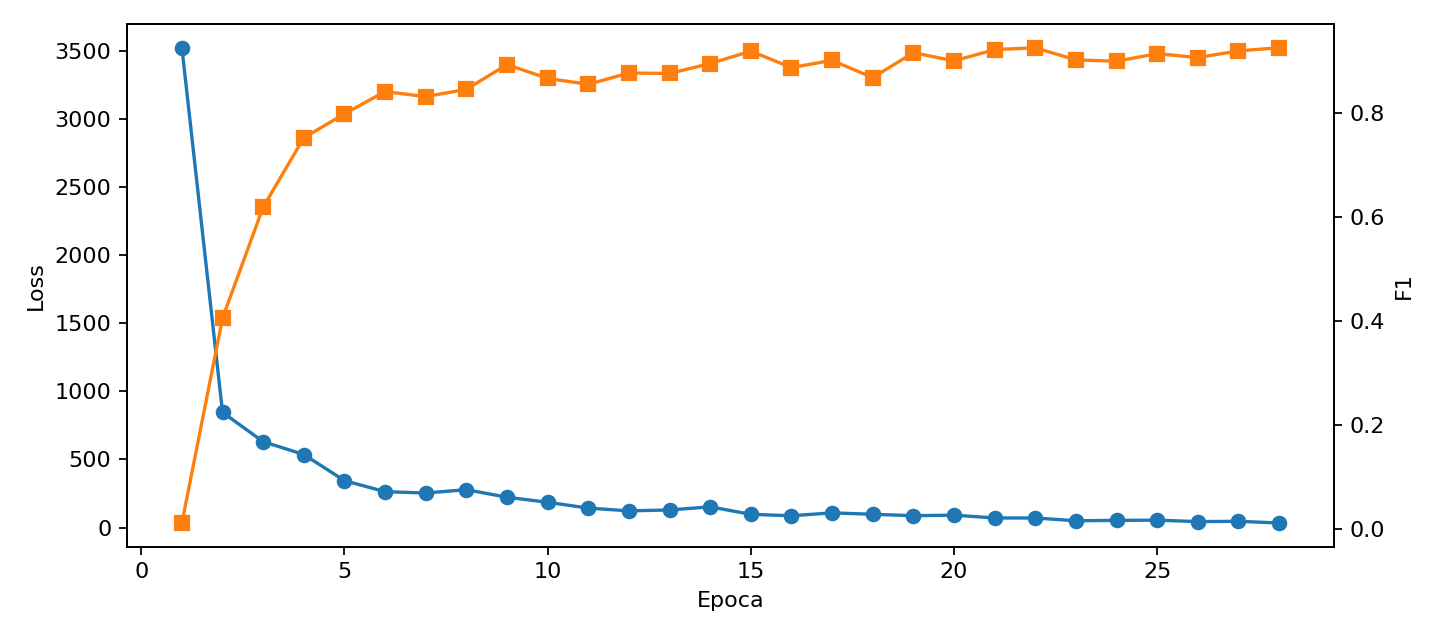

metricas_cluster.png


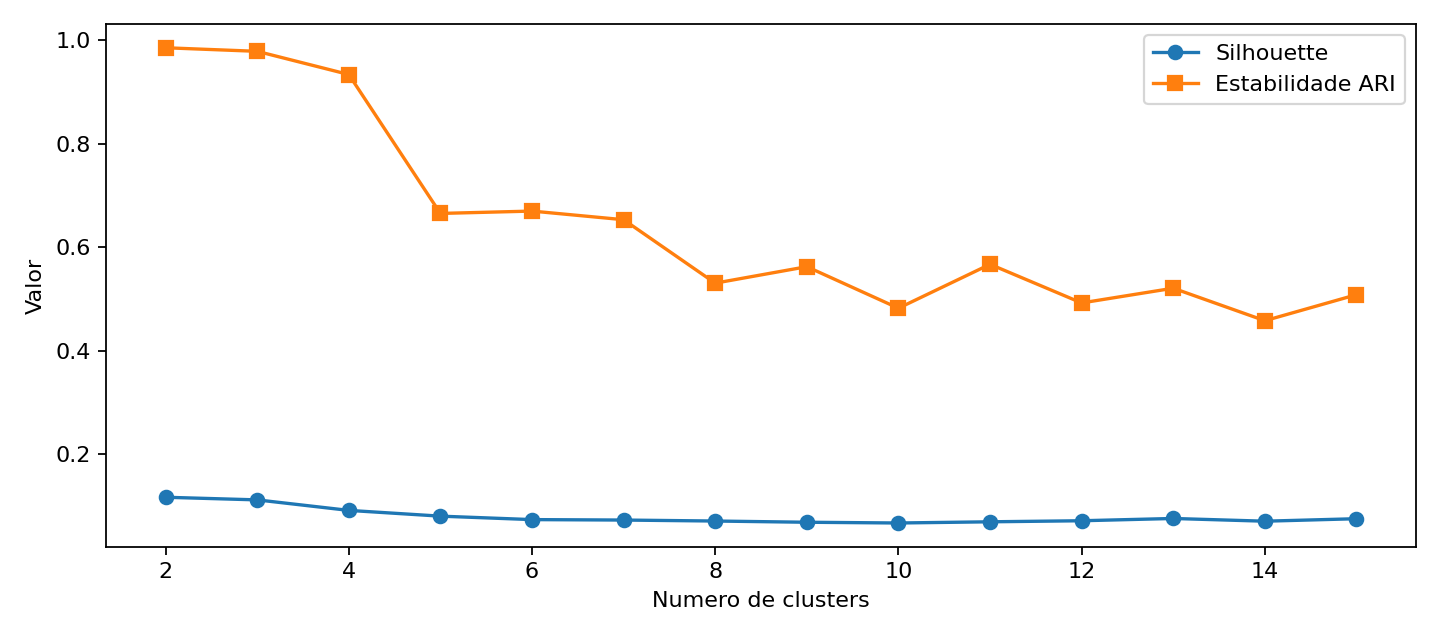

clusters_pca.png


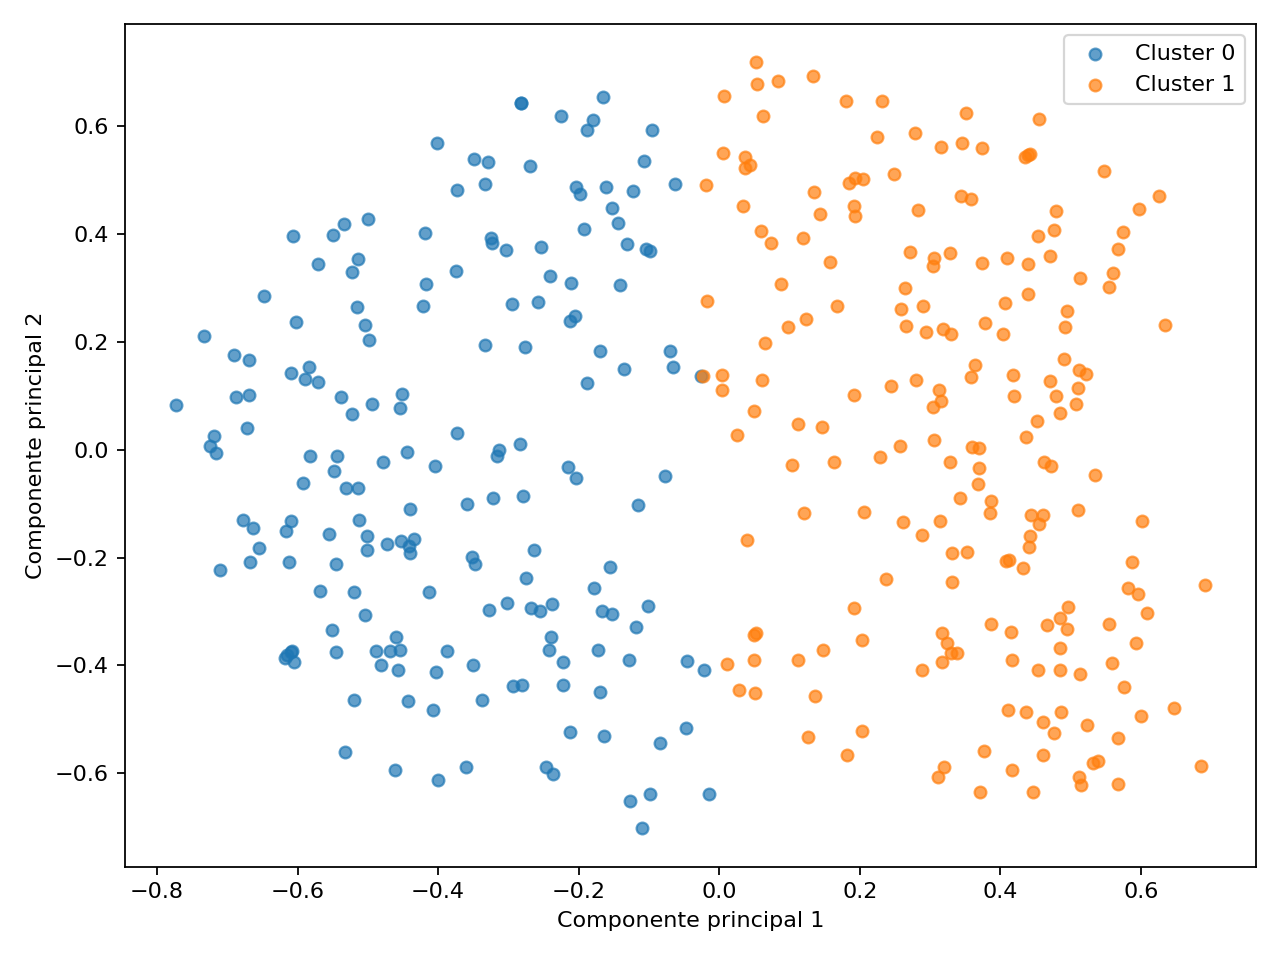

In [15]:
# CORRECAO: Image nao estava importada -- isso causava NameError na celula original
from IPython.display import Image, display as ipy_display

for nome in ['treinamento_ner.png', 'metricas_cluster.png', 'clusters_pca.png']:
    caminho = OUTPUT_DIR / 'figures' / nome
    if caminho.exists():
        print(nome)
        ipy_display(Image(filename=str(caminho)))
    else:
        print(f'[figura nao encontrada: {caminho}]')


## 16. Download do ZIP final

In [16]:
print('ZIP final:', ZIP_PATH.resolve())
try:
    from google.colab import files
    files.download(str(ZIP_PATH))
except Exception:
    print('No Kaggle, baixe o ZIP pelo painel de outputs.')

ZIP final: /kaggle/working/entrega_inovacoes_agro_final.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>